In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_excel('total_df.xlsx')
df

,Unnamed: 0,level_0,russian_title,english_title_kinopoisk,rating,vote_count_kinopoisk,genre,director,is_film,start_year,...,genre_tmdb_2,genre_tmdb_3,genre_tmdb_4,genre_tmdb_5,budget_tmdb,revenue_tmdb,company_creater_tmdb,buy_tmdb,rent_tmdb,keywords_tmdb
0,0,0,1+1,Intouchables,8.9,2791000.0,драма,Оливье Накаш,1.0,2011.0,...,35.0,NaN,NaN,NaN,13000000.0,426590315.0,NaN,[],[],NaN
1,1,1,Джентльмены,The Gentlemen,8.7,2473000.0,криминал,Гай Ричи,1.0,2019.0,...,80.0,NaN,NaN,NaN,22000000.0,115171795.0,NaN,"['Apple TV Store', 'Google Play Movies']","['Apple TV Store', 'Google Play Movies']",NaN
2,2,3,Гнев человеческий,Wrath of Man,7.7,1751000.0,боевик,Гай Ричи,1.0,2021.0,...,80.0,18.0,NaN,NaN,40000000.0,103966489.0,NaN,"['Apple TV Store', 'Google Play Movies', 'Kino...","['Apple TV Store', 'Google Play Movies']",NaN
3,3,4,Волк с Уолл-стрит,The Wolf of Wall Street,8.1,1716000.0,драма,Мартин Скорсезе,1.0,2013.0,...,18.0,35.0,NaN,NaN,100000000.0,407038432.0,NaN,[],[],NaN
4,4,5,Игра престолов,Game of Thrones,9.0,1497000.0,фэнтези,Дэвид Наттер,0.0,2011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[],NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41362,41362,72236,Банк Дэйва 2,Bank of Dave 2: The Loan Ranger,6.1,352.0,драма,Крис Фоггин,1.0,2025.0,...,18.0,NaN,NaN,NaN,NaN,NaN,NaN,[],[],NaN
41363,41363,72237,Безумные съёмки,Making Of,5.8,352.0,драма,Седрик Кан,1.0,2023.0,...,18.0,NaN,NaN,NaN,4000000.0,1261221.0,NaN,[],[],NaN
41364,41364,72238,Сделай это сам!!,Do It Yourself!!,7.1,352.0,аниме,Кадзухиро Ёнэда,0.0,2022.0,...,80.0,NaN,NaN,NaN,NaN,NaN,['Ealing Studios'],[],[],NaN
41365,41365,72239,Семейное проклятье,Klatwa,5.8,352.0,комедия,Томаш Конецки,1.0,2023.0,...,NaN,NaN,NaN,NaN,NaN,NaN,['Wonder Films'],[],[],NaN


In [44]:
print(f'Размер до удаления столбцов {df.shape}')

df.drop(['Unnamed: 0', 'level_0'], axis=1, inplace=True)

print(f'Размер после удаления столбцов {df.shape}')

Размер до удаления столбцов (41367, 33)
Размер после удаления столбцов (41367, 31)


In [45]:
df.columns

Index(['russian_title', 'english_title_kinopoisk', 'rating',
       'vote_count_kinopoisk', 'genre', 'director', 'is_film', 'start_year',
       'end_year', 'duration_minutes', 'country', 'actors',
       'english_title_tmdb', 'id_tmdb', 'overview_tmdb', 'release_date',
       'genre_ids_tmdb', 'popularity_tmdb', 'vote_average_tmdb',
       'vote_count_tmdb', 'genre_tmdb_1', 'genre_tmdb_2', 'genre_tmdb_3',
       'genre_tmdb_4', 'genre_tmdb_5', 'budget_tmdb', 'revenue_tmdb',
       'company_creater_tmdb', 'buy_tmdb', 'rent_tmdb', 'keywords_tmdb'],
      dtype='object')

## Анализ по жанру из кинопоиска

In [46]:
df_to_analysis = df[['genre', 'rating', 'vote_average_tmdb']]
df_to_analysis

,genre,rating,vote_average_tmdb
0,драма,8.9,8.269
1,криминал,8.7,7.662
2,боевик,7.7,7.600
3,драма,8.1,8.028
4,фэнтези,9.0,7.100
...,...,...,...
41362,драма,6.1,7.200
41363,драма,5.8,5.700
41364,аниме,7.1,5.100
41365,комедия,5.8,5.500


In [47]:
print(df_to_analysis['genre'].isna().sum())

df_to_analysis.dropna(subset=['genre', 'rating', 'vote_average_tmdb'], inplace=True)

print(df_to_analysis['genre'].isna().sum())

12
0


/var/folders/by/79crn8_s18g3gffy7r7hhb9c0000gn/T/ipykernel_63034/1901938004.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_to_analysis.dropna(subset=['genre', 'rating', 'vote_average_tmdb'], inplace=True)


In [48]:
df_to_analysis['genre'].nunique()

42

In [49]:
df_svod = df_to_analysis.groupby('genre').agg(
    rating_kinopoisk = ('rating', 'mean'),
    rating_tmdb = ('vote_average_tmdb', 'mean'),
    value_counts = ('rating', 'count')
).reset_index()

df_svod

,genre,rating_kinopoisk,rating_tmdb,value_counts
0,Режиссёр: J. Zachary Thurman,6.500000,5.000000,1
1,Режиссёр: Брэд Эпштейн,5.200000,4.700000,1
2,Режиссёр: Дарон Немеров,4.700000,6.500000,1
3,Режиссёр: Дэвид А. Уэйнер,8.000000,7.700000,1
4,Режиссёр: Дэвид В. Кеффер,3.900000,0.000000,1
5,Режиссёр: Кристофер Фарли,5.200000,4.000000,1
6,Режиссёр: Лев Додин,6.800000,5.000000,1
7,Режиссёр: Морган Сэкетт,7.600000,7.600000,1
8,Режиссёр: Томас Смит,5.200000,6.000000,1
9,Режиссёр: Фэб Файв Фредди,7.300000,6.200000,1


## Возьмем и посмотрим на самые популярные жанры

In [50]:
sorted_df = df_svod.sort_values(
    'value_counts',
    ascending=False
).reset_index()

sorted_df = sorted_df.drop('index', axis=1)
sorted_df

,genre,rating_kinopoisk,rating_tmdb,value_counts
0,драма,6.874052,6.050944,8860
1,ужасы,5.349003,5.378441,3761
2,триллер,6.422313,5.765020,2922
3,боевик,6.429002,5.860535,2855
4,комедия,6.477442,5.539676,2447
5,фантастика,6.146303,5.749899,1704
6,мультфильм,6.893039,6.417548,1609
7,мелодрама,6.787637,5.798637,1553
8,фэнтези,6.566908,5.886988,1242
9,аниме,7.238193,6.686260,830


**Уберем мусорные значения из поля 'genre'**

In [51]:
sorted_df_1 = sorted_df[sorted_df['value_counts'] != 1]
sorted_df_1 = sorted_df_1.iloc[:20, ]
sorted_df_1 = sorted_df_1.sort_values('value_counts')
sorted_df_1

,genre,rating_kinopoisk,rating_tmdb,value_counts
19,вестерн,6.871765,6.630682,85
18,военный,7.024419,6.590174,86
17,фильм-нуар,7.104615,6.593392,130
16,приключения,6.877692,5.919723,130
15,криминал,6.861026,5.983123,195
14,биография,7.101449,6.569324,207
13,детектив,6.964259,5.988224,263
12,документальный,7.372436,6.281221,312
11,мюзикл,6.956313,6.187202,396
10,короткометражка,6.772874,5.812720,435


In [52]:
sorted_df_2 = sorted_df[sorted_df['rating_kinopoisk'] != 1]
sorted_df_2 = sorted_df_2.iloc[:20, ]
sorted_df_2 = sorted_df_2.sort_values('rating_kinopoisk')
sorted_df_2

,genre,rating_kinopoisk,rating_tmdb,value_counts
1,ужасы,5.349003,5.378441,3761
5,фантастика,6.146303,5.749899,1704
2,триллер,6.422313,5.765020,2922
3,боевик,6.429002,5.860535,2855
4,комедия,6.477442,5.539676,2447
8,фэнтези,6.566908,5.886988,1242
10,короткометражка,6.772874,5.812720,435
7,мелодрама,6.787637,5.798637,1553
15,криминал,6.861026,5.983123,195
19,вестерн,6.871765,6.630682,85


In [53]:
sorted_df_3 = sorted_df[sorted_df['rating_tmdb'] != 1]
sorted_df_3 = sorted_df_3.iloc[:20, ]
sorted_df_3 = sorted_df_3.sort_values('rating_tmdb')
sorted_df_3

,genre,rating_kinopoisk,rating_tmdb,value_counts
1,ужасы,5.349003,5.378441,3761
4,комедия,6.477442,5.539676,2447
5,фантастика,6.146303,5.749899,1704
2,триллер,6.422313,5.765020,2922
7,мелодрама,6.787637,5.798637,1553
10,короткометражка,6.772874,5.812720,435
3,боевик,6.429002,5.860535,2855
8,фэнтези,6.566908,5.886988,1242
16,приключения,6.877692,5.919723,130
15,криминал,6.861026,5.983123,195


### Построим график "Топ-20 жанров по частоте в выборке"

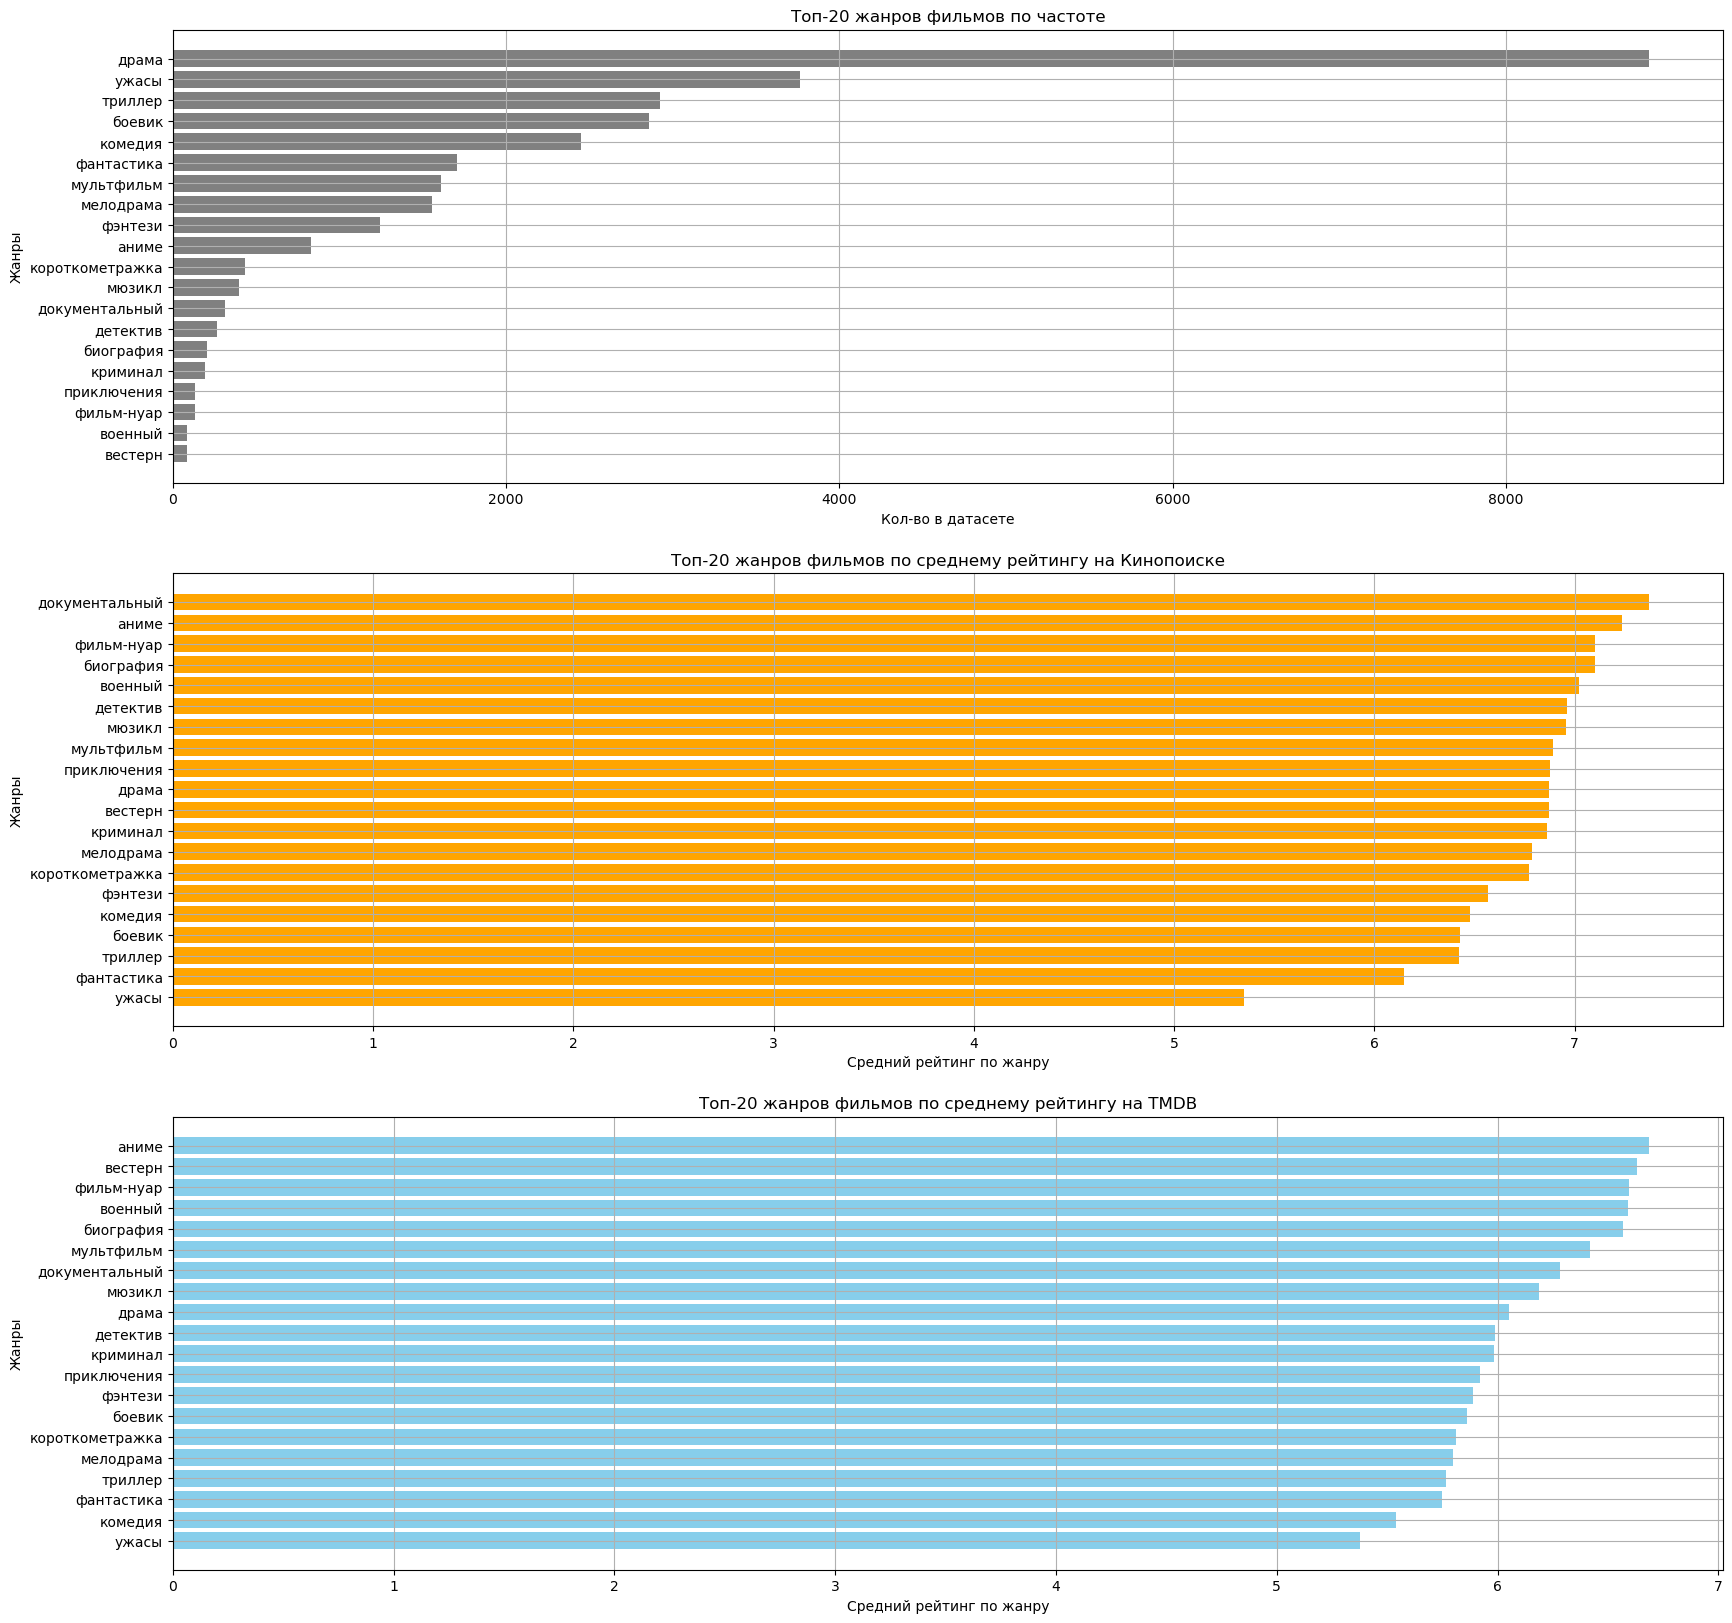

In [55]:
fig, ax = plt.subplots(3, 1, figsize=(20, 20))

ax[0].barh(
    sorted_df_1['genre'], 
    sorted_df_1['value_counts'],
    color = 'grey'
)
ax[0].set_title('Топ-20 жанров фильмов по частоте')
ax[0].set_xlabel('Кол-во в датасете')
ax[0].set_ylabel('Жанры')
ax[0].grid()



ax[1].barh(
    sorted_df_2['genre'], 
    sorted_df_2['rating_kinopoisk'],
    color = 'orange'
)
ax[1].set_title('Топ-20 жанров фильмов по cреднему рейтингу на Кинопоиске')
ax[1].set_xlabel('Средний рейтинг по жанру')
ax[1].set_ylabel('Жанры')
ax[1].grid()



ax[2].barh(
    sorted_df_3['genre'], 
    sorted_df_3['rating_tmdb'],
    color = 'skyblue'
)
ax[2].set_title('Топ-20 жанров фильмов по cреднему рейтингу на TMDB')
ax[2].set_xlabel('Средний рейтинг по жанру')
ax[2].set_ylabel('Жанры')
ax[2].grid()

plt.show()